In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import sys
sys.path.append("..")

from plotting_tools import * 

In [ ]:
station = "S_M4"
timepoints = [0, 360, 720]
dfs = []

for t in timepoints:
    station_file = f"infection_age_shedding_{t}_{station}.csv"
    df = pd.read_csv(station_file)
    dfs.append(df)

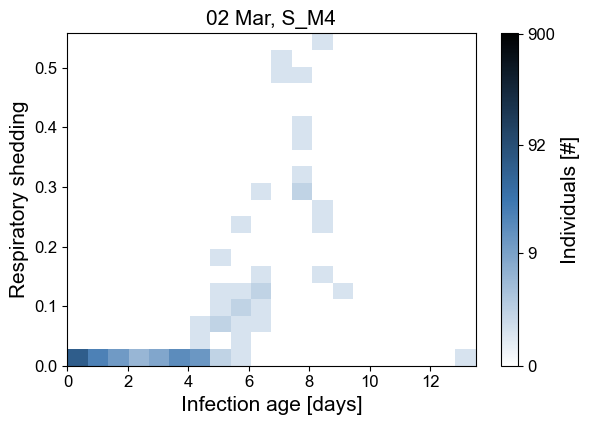

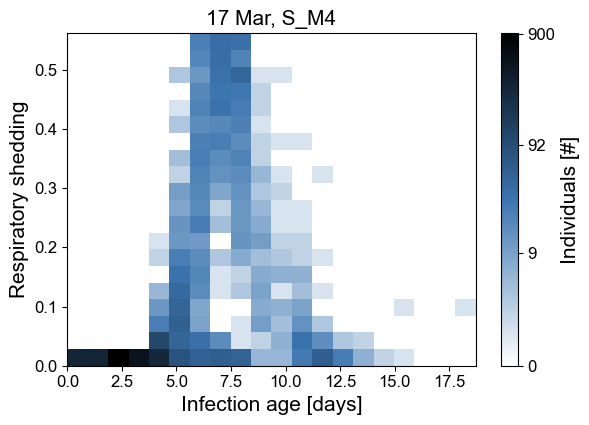

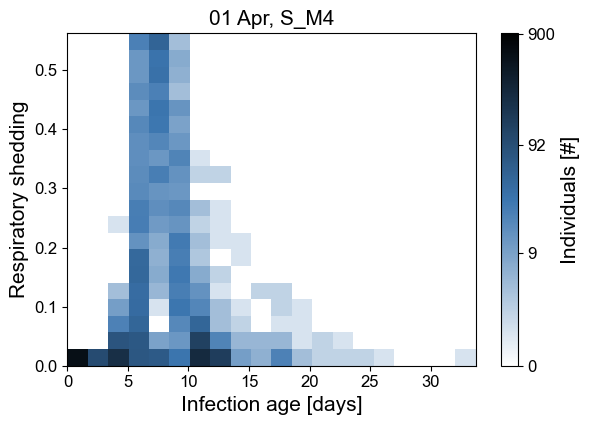

In [41]:
for i, df in enumerate(dfs):
    fig, ax = plt.subplots(figsize=(6.2, 4.5))

    start_date = datetime(2020, 3, 2)
    date = (start_date + timedelta(hours=int(timepoints[i]))).strftime('%d %b')

    custom_cmap_blue = mcolors.LinearSegmentedColormap.from_list('custom_blue', [colors['White'], colors['Blue'], colors['Black']])
    norm = Log1pNorm(vmin=0, vmax=912) 

    h = ax.hist2d(
        df.infection_age/24.,
        df.shedding,
        bins=20,
        cmap=custom_cmap_blue,
        norm=norm
    )

    cbar = fig.colorbar(h[3], ax=ax)
    cbar.set_label('Individuals [#]')
    n_ticks = 4
    normed_positions = np.linspace(0, norm(900), n_ticks)
    tick_values = [int(np.round(norm.inverse(p))) for p in normed_positions]
    cbar.set_ticks(tick_values)
    cbar.set_ticklabels([f"{tick}" for tick in tick_values])

    ax.set_xlabel('Infection age [days]')
    ax.set_ylabel('Respiratory shedding')

    ax.set_title(f'{date}, {station}')

    plt.tight_layout()
    fig.savefig(f"infection_age_shedding_{date}_{station}", dpi=dpi)
    plt.show()

C:\Users\bick_ju\AppData\Local\Temp\ipykernel_19032\2349218220.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_a = df.groupby("age_bin")["shedding"].mean().dropna()
C:\Users\bick_ju\AppData\Local\Temp\ipykernel_19032\2349218220.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


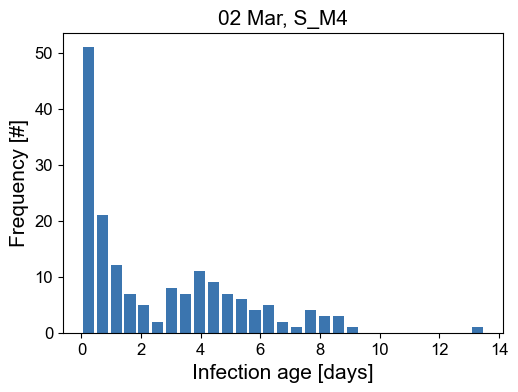

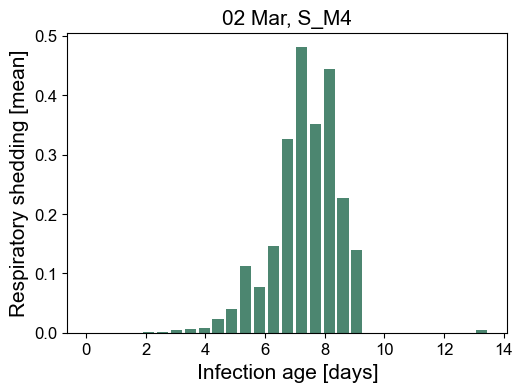

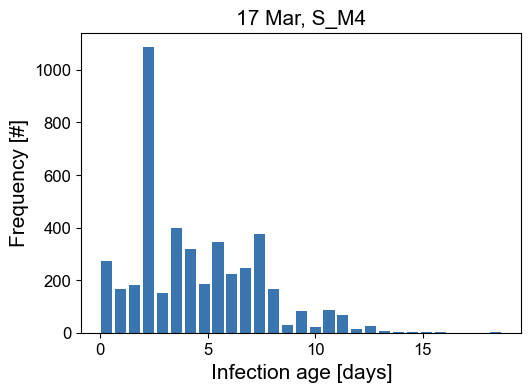

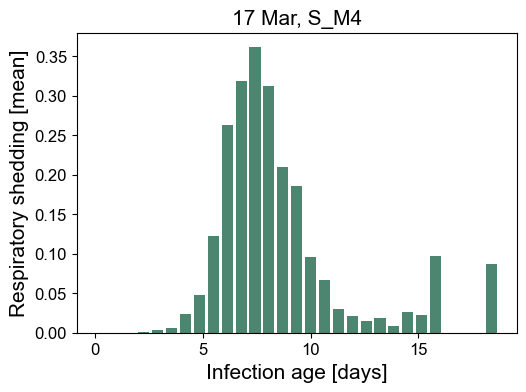

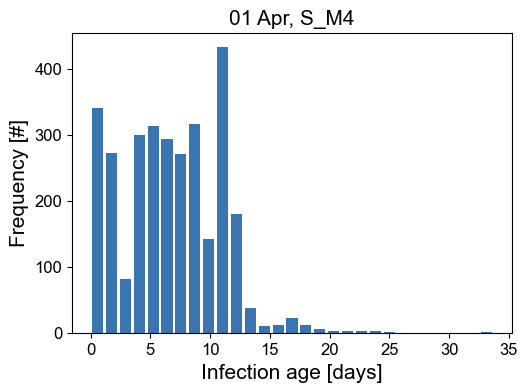

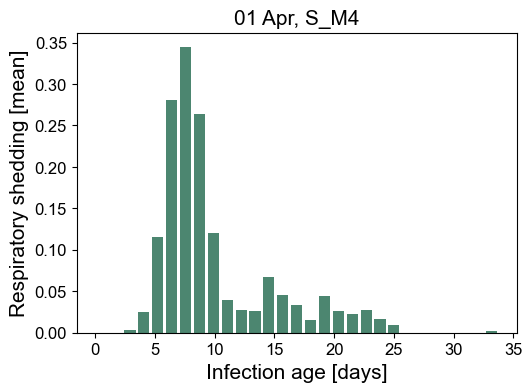

In [43]:
for i, df in enumerate(dfs):
    panel = [0.15, 0.15, 0.8, 0.75]
    figsize = (5.5, 4)
    fig1 = plt.figure(figsize=figsize)
    ax1 = fig1.add_axes(panel)
    fig2 = plt.figure(figsize=figsize)
    ax2 = fig2.add_axes(panel)

    start_date = datetime(2020, 3, 2)
    date = (start_date + timedelta(hours=int(timepoints[i]))).strftime('%d %b')   
    
    bins = np.linspace((df.infection_age/24.).min(), (df.infection_age/24.).max(), 30)
    ax1.hist(df.infection_age/24., bins=bins, color=colors['Blue'], rwidth=0.8)
    df["age_bin"] = pd.cut(df.infection_age/24., bins)
    mean_a = df.groupby("age_bin")["shedding"].mean().dropna()
    bin_centers = np.array([interval.mid for interval in mean_a.index])
    bin_widths = np.array([interval.length for interval in mean_a.index])
    ax2.bar(bin_centers,  mean_a.values, width=0.8 * bin_widths, color=colors['Teal'])

    ax1.set_xlabel('Infection age [days]')
    ax1.set_ylabel('Frequency [#]')
    ax1.set_title(f'{date}, {station}')
    
    ax2.set_xlabel('Infection age [days]')
    ax2.set_ylabel('Respiratory shedding [mean]')
    ax2.set_title(f'{date}, {station}')

    plt.tight_layout()
    fig1.savefig(f"infection_age_{date}_{station}", dpi=dpi)
    fig2.savefig(f"shedding_{date}_{station}", dpi=dpi)
    plt.show()